In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.utils import resample
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler


from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay, roc_curve, roc_auc_score

import joblib
import os


### Read data

In [ ]:
# Read features
dist_data = pd.read_csv('../data/Su_2020/selected_structures.tsv', sep='\t')

# Read transcriptional data
transc_data = pd.read_csv('../data/Su_2020/transcriptional_data.tsv', sep='\t')

### Check data distribution

In [193]:
dist_data.head(2)

,Chromosome copy number,1-2,1-3,1-4,1-5,1-6,1-7,1-8,1-9,1-10,...,34-35,34-36,34-37,34-38,35-36,35-37,35-38,36-37,36-38,37-38
0,3,406.137908,208.278659,180.540854,532.109011,432.177047,252.944658,196.158100,103.643620,452.192437,...,165.918655,177.589414,845.345492,308.016233,261.291025,818.017115,236.788936,748.332146,242.960902,742.189329
1,7,372.927607,551.823341,531.536452,528.043559,503.838268,318.499608,243.517966,461.937225,407.748697,...,355.828610,344.020348,117.341382,425.809817,210.518408,249.148550,76.197113,237.168716,225.809654,317.743607


In [194]:
transc_data.head(2)

,Chromosome copy number,BACH1,CCT8,LTN1,N6AMT1,USP16
0,3,0,1,0,0,0
1,7,1,0,0,0,0


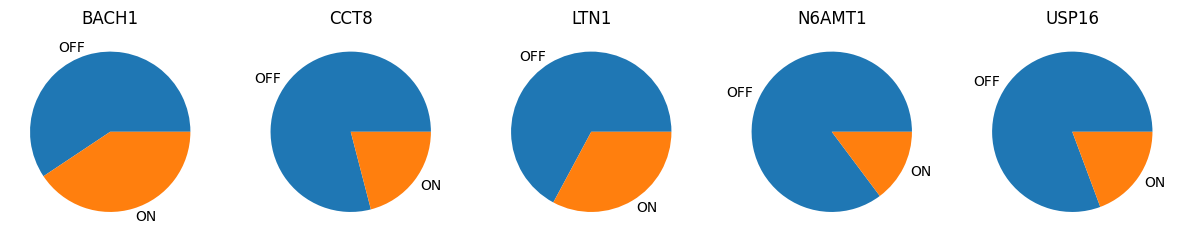

In [195]:
gene_names = transc_data.columns[1:].tolist()

fig, axs = plt.subplots(1, 5, figsize=(15, 3))

for i, gene in enumerate(gene_names):
    axs[i].pie(transc_data[gene].value_counts(), labels=['OFF', 'ON'])
    axs[i].set_title(f"{gene}")


### Preprocess data

##### Will use data from BACH1 gene, which is the most balaced dataset (328 OFF vs 237 ON)

In [196]:
dataset = pd.merge(dist_data, transc_data.iloc[:, :2], how='left', on='Chromosome copy number').iloc[:, 1:]

X = dataset.iloc[:, :-1].to_numpy()
Y = dataset.iloc[:, -1].to_numpy()

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reduce dimensions - I have many and very correlated!
#pca = PCA(n_components = 0.95)
#X_train = pca.fit_transform(X_train)
#X_test = pca.transform(X_test)

In [197]:
X_train.shape

(2550, 703)

### Create model - use grid search for hyperparameter tuning

In [ ]:
# Define parameter search - Try with extra space to reduce overfitting!
param_grid = {
    'class_weight': [None, 'balanced'],
    'max_depth': [None, 5, 10, 15, 20],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'n_estimators': [25, 50, 100, 150, 200, 300, 400, 500, 600],
}


In [204]:
# Define cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [205]:
# Define model
random_forest_model = RandomForestClassifier(random_state=42, class_weight='balanced')

In [206]:
# Initialize model with grid search
grid_search_random_forest_model = GridSearchCV(estimator=random_forest_model,
                                               param_grid = param_grid,
                                               cv=cv,
                                               scoring='f1_weighted',
                                               n_jobs=-1,
                                               verbose=2)

### Fit model - using entire parameter space

In [207]:
hist = grid_search_random_forest_model.fit(X_train, y_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
[CV] END ccp_alpha=0.0, class_weight=balanced, max_depth=5, max_features=sqrt, max_samples=0.5, min_samples_leaf=1, min_samples_split=5, n_estimators=400; total time=   3.5s
[CV] END ccp_alpha=0.0, class_weight=balanced, max_depth=5, max_features=sqrt, max_samples=0.5, min_samples_leaf=1, min_samples_split=5, n_estimators=400; total time=   3.5s
[CV] END ccp_alpha=0.0, class_weight=balanced, max_depth=5, max_features=sqrt, max_samples=0.5, min_samples_leaf=1, min_samples_split=5, n_estimators=400; total time=   3.5s
[CV] END ccp_alpha=0.0, class_weight=balanced, max_depth=5, max_features=sqrt, max_samples=0.5, min_samples_leaf=1, min_samples_split=5, n_estimators=400; total time=   3.6s
[CV] END ccp_alpha=0.0, class_weight=balanced, max_depth=5, max_features=sqrt, max_samples=0.5, min_samples_leaf=1, min_samples_split=5, n_estimators=400; total time=   3.5s
[CV] END ccp_alpha=0.0, class_weight=balanced, max_depth=5, max_fe

### Save hyperparameter tuning results

In [ ]:
joblib.dump(grid_search_random_forest_model, "../results/random_forest/gridsearch_results_random_forest.pkl")

grid_search_df = pd.DataFrame(grid_search_random_forest_model.cv_results_)
grid_search_df.to_csv("../results/random_forest/gridsearch_results_random_forest.tsv", index=False, sep='\t')

In [209]:
print('The best hyperparameters found using 5-fold cross-validation are:')
print(grid_search_random_forest_model.best_params_)

with open('../results/random_forest/hyperparams.txt', 'w') as f:
    f.write('The best hyperparameters found using 5-fold cross-validation are:\n')
    for key in grid_search_random_forest_model.best_params_:
        f.write(f"{key}: {grid_search_random_forest_model.best_params_[key]}\n")

The best hyperparameters found using 5-fold cross-validation are:
{'ccp_alpha': 0.0, 'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 500}


### Calculate predictions and plot metrics

In [ ]:
# Select best model
best_model = grid_search_random_forest_model.best_estimator_
#best_model = RandomForestClassifier(random_state=42, class_weight='balanced', max_depth=5, max_features='sqrt',
#                                    min_samples_leaf=1, min_samples_split=10, n_estimators=500, oob_score=True)
#best_model.fit(X_train, y_train)

# Calculate predictions
y_pred = best_model.predict(X_test)
y_pred_scores = best_model.predict_proba(X_test)[:,1]

# Calculate predictions on training dataset
y_pred_train = best_model.predict(X_train)
y_pred_train_scores = best_model.predict_proba(X_train)[:,1]

In [228]:
# Classification report
class_report = classification_report(y_test, y_pred)

# Confusion matrics
conf_matrix = confusion_matrix(y_test, y_pred)

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_scores)
auc = roc_auc_score(y_test, y_pred_scores)

# training ROC
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_pred_train_scores)
auc_train = roc_auc_score(y_train, y_pred_train_scores)

In [229]:
# Compute OOB performance
oob_acc = best_model.oob_score_

y_oob_prob = best_model.oob_decision_function_[:, 1]

fpr_oob, tpr_oob, thresholds_oob = roc_curve(y_train, y_oob_prob)
auc_oob = roc_auc_score(y_train, y_oob_prob)


In [230]:
# Print classification report
print(class_report)

with open('../results/random_forest/classification_report.txt', 'w') as f:
    f.write(class_report)

              precision    recall  f1-score   support

           0       0.63      0.67      0.65       379
           1       0.47      0.42      0.44       259

    accuracy                           0.57       638
   macro avg       0.55      0.55      0.55       638
weighted avg       0.56      0.57      0.57       638



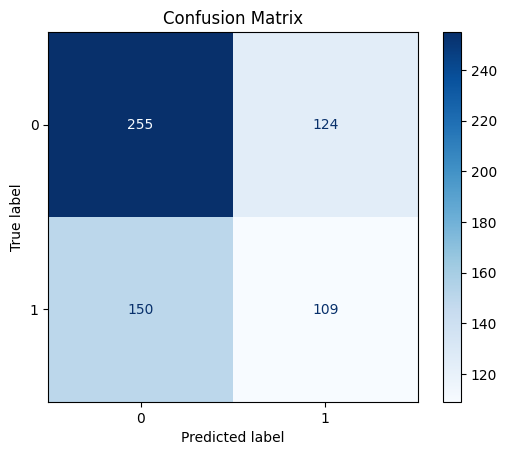

In [231]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

disp.figure_.savefig('../results/random_forest/confusion_matrix.pdf', format='pdf')

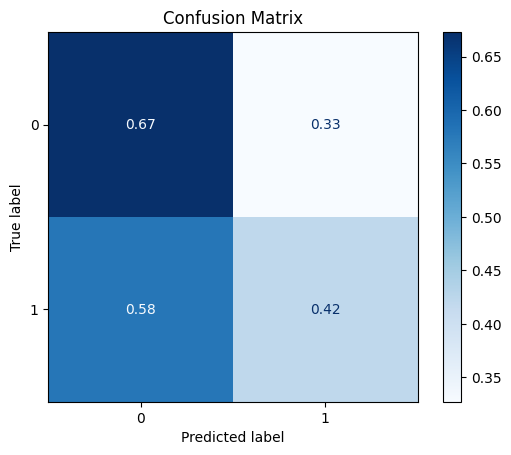

In [232]:
# Normalized confusion matrix
cm_norm = conf_matrix.astype(float) / conf_matrix.sum(axis=1)[:, None]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

disp.figure_.savefig('../results/random_forest/confusion_matrix_normalized.pdf', format='pdf')

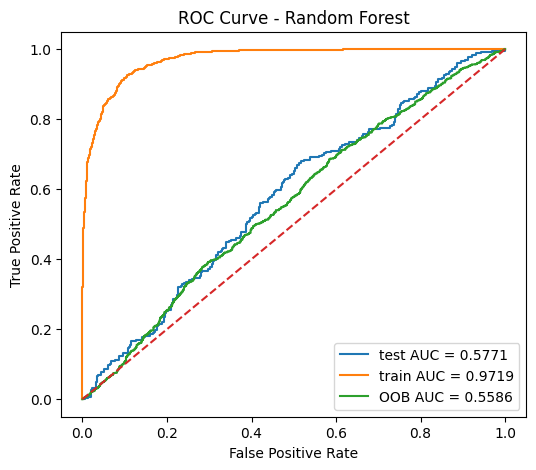

In [233]:

# ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"test AUC = {auc:.4f}")
plt.plot(fpr_train, tpr_train, label=f"train AUC = {auc_train:.4f}")
plt.plot(fpr_oob, tpr_oob, label=f"OOB AUC = {auc_oob:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.savefig('../results/random_forest/ROC.pdf', format='pdf')

In [129]:
# Get feture importances
n_feats = 20
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1][:n_feats]
features = dataset.columns[:-1]

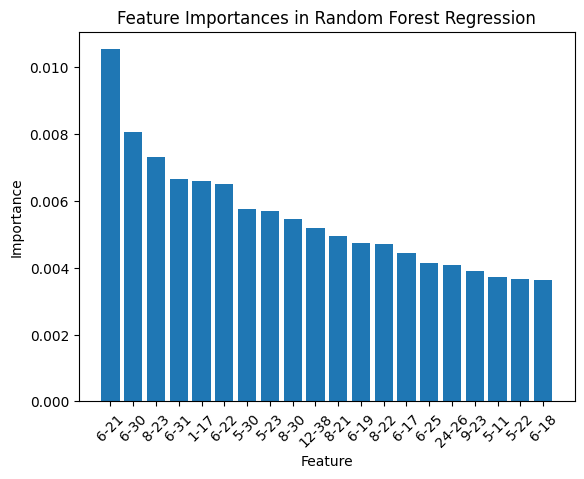

In [130]:
# Plot feature importances
plt.bar(range(n_feats), importances[indices],  align="center")
plt.xticks(range(n_feats), [features[i] for i in indices], rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances in Random Forest Regression")

plt.savefig('../results/random_forest/feature_importance.pdf', format='pdf')

## Redo analysis using best-tuned model and bigger dataset (more flexible filtering)

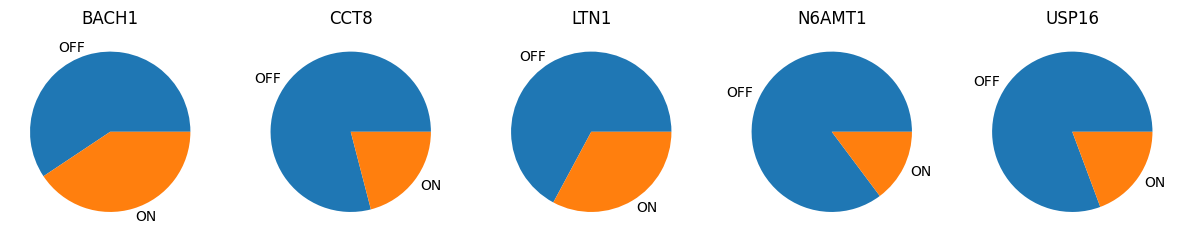

In [141]:
# Read features
dist_data = pd.read_csv('../data/Su_2020/selected_structures_1000_nm_thr.tsv', sep='\t')

# Read transcriptional data
transc_data = pd.read_csv('../data/Su_2020/transcriptional_data_1000_nm_thr.tsv', sep='\t')

gene_names = transc_data.columns[1:].tolist()

fig, axs = plt.subplots(1, 5, figsize=(15, 3))

for i, gene in enumerate(gene_names):
    axs[i].pie(transc_data[gene].value_counts(), labels=['OFF', 'ON'])
    axs[i].set_title(f"{gene}")

In [142]:
dataset = pd.merge(dist_data, transc_data.iloc[:, :2], how='left', on='Chromosome copy number').iloc[:, 1:]

X = dataset.iloc[:, :-1].to_numpy()
Y = dataset.iloc[:, -1].to_numpy()

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reduce dimensions - I have many and very correlated!
# pca = PCA(n_components = 0.9)
# X_train = pca.fit_transform(X_train)
# X_test = pca.transform(X_test)

In [143]:
X_train.shape

(2550, 703)

### Create model - use grid search for hyperparameter tuning

In [144]:
# Define parameter search
param_grid = {
    'class_weight': [None, 'balanced'],
    'max_depth': [None, 5, 10, 15, 20],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'n_estimators': [25, 50, 100, 150, 200, 300, 400, 500, 600],
}

In [145]:
# Define cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [146]:
random_forest_model = RandomForestClassifier(random_state=42, class_weight='balanced')

In [147]:
# Initialize model with grid search
grid_search_random_forest_model = GridSearchCV(estimator=random_forest_model,
                                               param_grid = param_grid,
                                               cv=cv,
                                               scoring='f1_weighted',
                                               n_jobs=-1,
                                               verbose=2)

In [97]:
# Train model
#random_forest_model = RandomForestClassifier(random_state=42, class_weight='balanced', max_depth=5, max_features='sqrt',
#                                             min_samples_leaf=1, min_samples_split=10, n_estimators=500
#                                             )

In [148]:
hist = grid_search_random_forest_model.fit(X_train, y_train)

Fitting 5 folds for each of 2430 candidates, totalling 12150 fits
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=25; total time=   0.7s
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=25; total time=   0.7s
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=25; total time=   0.7s
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=25; total time=   0.7s
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=25; total time=   0.7s
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   1.4s
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples

### Save hyperparameter tuning results

In [149]:
joblib.dump(grid_search_random_forest_model, "../results/random_forest/gridsearch_results_random_forest_1000_nm_thr.pkl")

grid_search_df = pd.DataFrame(grid_search_random_forest_model.cv_results_)
grid_search_df.to_csv("../results/random_forest/gridsearch_results_random_forest_1000_nm_thr.tsv", index=False, sep='\t')

In [150]:
print('The best hyperparameters found using 5-fold cross-validation are:')
print(grid_search_random_forest_model.best_params_)

with open('../results/random_forest/hyperparams_1000_nm_thr.txt', 'w') as f:
    f.write('The best hyperparameters found using 5-fold cross-validation are:\n')
    for key in grid_search_random_forest_model.best_params_:
        f.write(f"{key}: {grid_search_random_forest_model.best_params_[key]}\n")

The best hyperparameters found using 5-fold cross-validation are:
{'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 500}


### Calculate predictions and plot metrics

In [151]:
best_model = grid_search_random_forest_model.best_estimator_

# Calculate predictions
y_pred = best_model.predict(X_test)
y_pred_scores = best_model.predict_proba(X_test)[:,1]

# Calculate predictions on training dataset
y_pred_train = best_model.predict(X_train)
y_pred_train_scores = best_model.predict_proba(X_train)[:,1]

In [152]:
# Classification report
class_report = classification_report(y_test, y_pred)

# Confusion matrics
conf_matrix = confusion_matrix(y_test, y_pred)

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_scores)
auc = roc_auc_score(y_test, y_pred_scores)

# training ROC
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_pred_train_scores)
auc_train = roc_auc_score(y_train, y_pred_train_scores)

In [153]:
# Print classification report
print(class_report)

with open('../results/random_forest/classification_report_1000_nm_thr.txt', 'w') as f:
    f.write(class_report)

              precision    recall  f1-score   support

           0       0.64      0.67      0.65       379
           1       0.48      0.44      0.46       259

    accuracy                           0.58       638
   macro avg       0.56      0.56      0.56       638
weighted avg       0.57      0.58      0.58       638



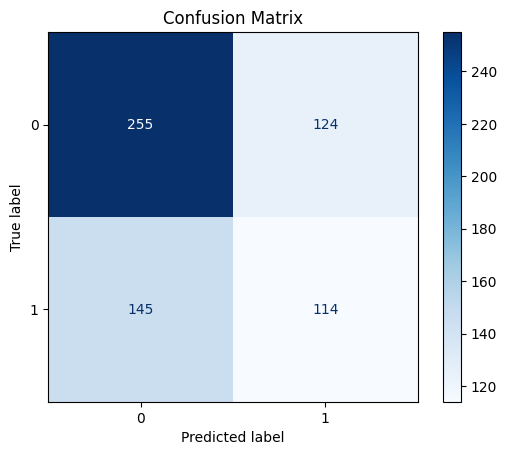

In [154]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

disp.figure_.savefig('../results/random_forest/confusion_matrix_1000_nm_thr.pdf', format='pdf')

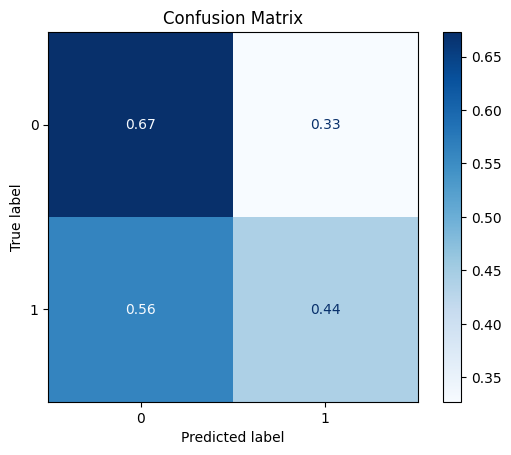

In [155]:
# Normalized confusion matrix
cm_norm = conf_matrix.astype(float) / conf_matrix.sum(axis=1)[:, None]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

disp.figure_.savefig('../results/random_forest/confusion_matrix_normalized_1000_nm_thr.pdf', format='pdf')

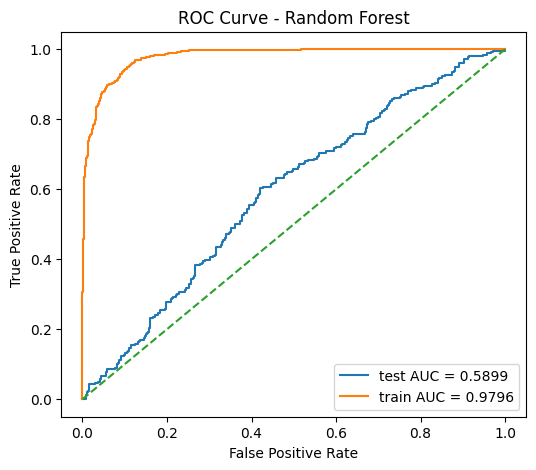

In [156]:
# ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"test AUC = {auc:.4f}")
plt.plot(fpr_train, tpr_train, label=f"train AUC = {auc_train:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.savefig('../results/random_forest/ROC_1000_nm_thr.pdf', format='pdf')

In [158]:
# Get feture importances
n_feats = 20
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1][:n_feats]
features = dataset.columns[:-1]

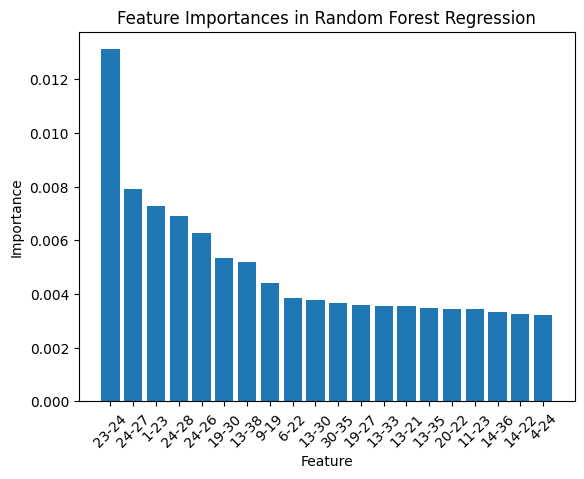

In [159]:
# Plot feature importances
plt.bar(range(n_feats), importances[indices],  align="center")
plt.xticks(range(n_feats), [features[i] for i in indices], rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances in Random Forest Regression")

plt.savefig('../results/random_forest/feature_importance_1000_nm_thr.pdf', format='pdf')

## Redo DNA-MERFISH analysis using simulations

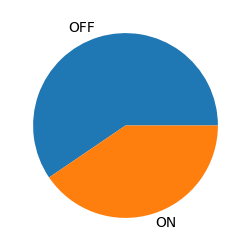

In [2]:
# Read distance matrices with transcriptional information
dists_path = '../data/Su_2020/simulated_dataset/matrices_transformed_classified/'

mats_vector = []
for state in ['active', 'inactive']:
    mats = os.listdir(f"{dists_path}/{state}")
    
    for mat_i_name in mats:
        mat_i = pd.read_csv(f"{dists_path}/{state}/{mat_i_name}", sep='\t', header=None).to_numpy()
        
        mat_i_vector = []
        for i in range(0, mat_i.shape[0]):
            for j in range(i+ 1, mat_i.shape[1]):
                mat_i_vector.append(mat_i[i,j])

        if state == 'active':
            mat_i_vector.append(1)
        else:
            mat_i_vector.append(0)

        mats_vector.append(mat_i_vector)
        
mats_vector = pd.DataFrame(mats_vector)

# Plot distribution
fig, axs = plt.subplots(1, 1, figsize=(3, 3))

axs.pie(mats_vector.iloc[:, -1].value_counts(), labels=['OFF', 'ON'])

plt.show()

In [3]:
X = mats_vector.iloc[:, :-1].to_numpy()
Y = mats_vector.iloc[:, -1].to_numpy()

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reduce dimensions - I have many and very correlated!
# pca = PCA(n_components = 0.9)
# X_train = pca.fit_transform(X_train)
# X_test = pca.transform(X_test)

In [4]:
X_train.shape

(2412, 703)

### Create model - use grid search for hyperparameter tuning

In [ ]:
# Define pipeline
pipe = Pipeline([
    ("under", RandomUnderSampler(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42))
])

In [ ]:
# Define parameter search
param_grid = {
    "rf__class_weight": [None, "balanced"],
    "rf__max_depth": [None, 5, 10, 15, 20],
    "rf__max_features": ["sqrt", "log2", None],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__min_samples_split": [2, 5, 10],
    "rf__n_estimators": [25, 50, 100, 150, 200, 300, 400, 500, 600],
}

In [97]:
# Define cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [98]:
random_forest_model = RandomForestClassifier(random_state=42, class_weight='balanced')

In [ ]:
# Initialize model with grid search
grid_search_random_forest_model = GridSearchCV(estimator=pipe,
                                               param_grid = param_grid,
                                               cv=cv,
                                               scoring='f1_weighted',
                                               n_jobs=-1,
                                               verbose=2)

In [100]:
# Train model
#random_forest_model = RandomForestClassifier(random_state=42, class_weight='balanced', max_depth=5, max_features='sqrt',
#                                             min_samples_leaf=1, min_samples_split=10, n_estimators=500
#                                             )

In [101]:
hist = grid_search_random_forest_model.fit(X_train, y_train)

Fitting 5 folds for each of 2430 candidates, totalling 12150 fits
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=25; total time=   0.5s
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=25; total time=   0.5s
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=25; total time=   0.5s
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=25; total time=   0.5s
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=25; total time=   0.5s
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   1.0s
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples

KeyboardInterrupt: 

### Save hyperparameter tuning results

In [ ]:
joblib.dump(grid_search_random_forest_model, "../results/random_forest/gridsearch_results_random_forest_simulated.pkl")

grid_search_df = pd.DataFrame(grid_search_random_forest_model.cv_results_)
grid_search_df.to_csv("../results/random_forest/gridsearch_results_random_forest_simulated.tsv", index=False, sep='\t')

In [ ]:
print('The best hyperparameters found using 5-fold cross-validation are:')
print(grid_search_random_forest_model.best_params_)

with open('../results/random_forest/hyperparams_simulated.txt', 'w') as f:
    f.write('The best hyperparameters found using 5-fold cross-validation are:\n')
    for key in grid_search_random_forest_model.best_params_:
        f.write(f"{key}: {grid_search_random_forest_model.best_params_[key]}\n")

The best hyperparameters found using 5-fold cross-validation are:
{'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 500}


### Calculate predictions and plot metrics

In [ ]:
best_model = grid_search_random_forest_model.best_estimator_

# Calculate predictions
y_pred = best_model.predict(X_test)
y_pred_scores = best_model.predict_proba(X_test)[:,1]

# Calculate predictions on training dataset
y_pred_train = best_model.predict(X_train)
y_pred_train_scores = best_model.predict_proba(X_train)[:,1]

In [ ]:
# Classification report
class_report = classification_report(y_test, y_pred)

# Confusion matrics
conf_matrix = confusion_matrix(y_test, y_pred)

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_scores)
auc = roc_auc_score(y_test, y_pred_scores)

# training ROC
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_pred_train_scores)
auc_train = roc_auc_score(y_train, y_pred_train_scores)

In [ ]:
# Print classification report
print(class_report)

with open('../results/random_forest/classification_report_simulated.txt', 'w') as f:
    f.write(class_report)

              precision    recall  f1-score   support

           0       0.64      0.67      0.65       379
           1       0.48      0.44      0.46       259

    accuracy                           0.58       638
   macro avg       0.56      0.56      0.56       638
weighted avg       0.57      0.58      0.58       638



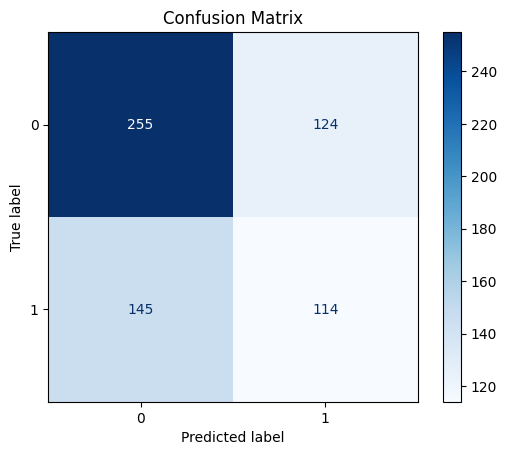

In [ ]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

disp.figure_.savefig('../results/random_forest/confusion_matrix_simulated.pdf', format='pdf')

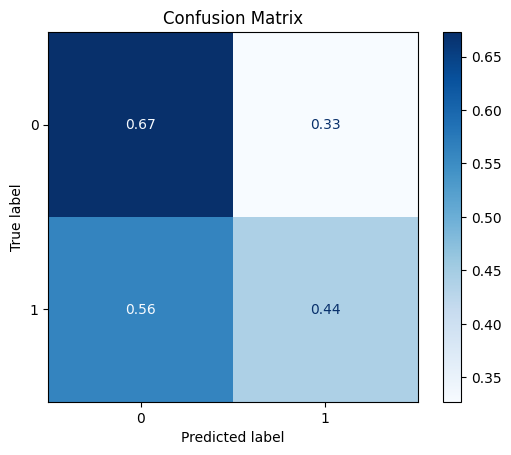

In [ ]:
# Normalized confusion matrix
cm_norm = conf_matrix.astype(float) / conf_matrix.sum(axis=1)[:, None]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

disp.figure_.savefig('../results/random_forest/confusion_matrix_normalized_simulated.pdf', format='pdf')

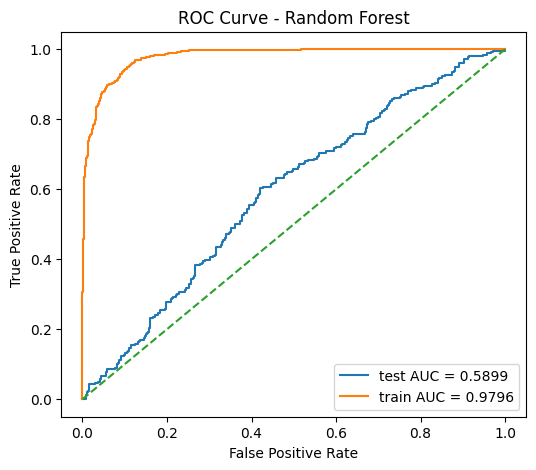

In [ ]:
# ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"test AUC = {auc:.4f}")
plt.plot(fpr_train, tpr_train, label=f"train AUC = {auc_train:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.savefig('../results/random_forest/ROC_simulated.pdf', format='pdf')

In [ ]:
# Get feture importances
n_feats = 20
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1][:n_feats]
features = dataset.columns[:-1]

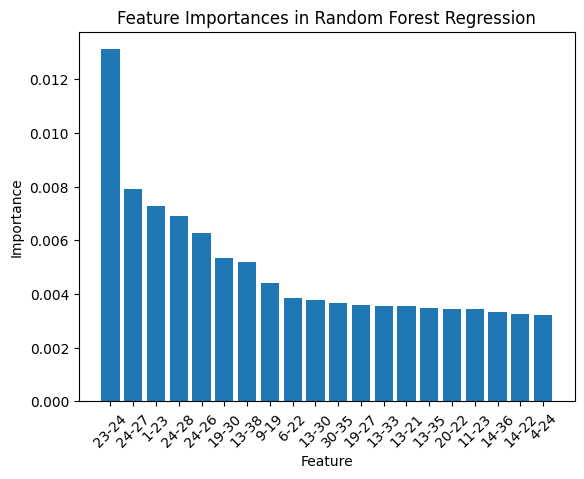

In [ ]:
# Plot feature importances
plt.bar(range(n_feats), importances[indices],  align="center")
plt.xticks(range(n_feats), [features[i] for i in indices], rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances in Random Forest Regression")

plt.savefig('../results/random_forest/feature_importance_simulated.pdf', format='pdf')